## Visualization with t-SNE and Bokeh

In [1]:
# Basic
import numpy as np
import pandas as pd
# Plots
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
# Clustering
from sklearn.manifold import TSNE
from sklearn import cluster
# Bokeh
from bokeh.io import output_notebook
from bokeh.plotting import figure, show, ColumnDataSource
from bokeh.models import HoverTool

In [2]:
%matplotlib inline
output_notebook()

Loading BokehJS ...

In [3]:
df_train = pd.read_csv('../input/train.csv')  # load train
df_test = pd.read_csv('../input/test.csv')    # load test
y = df_train.pop('SalePrice')        # pop sales from train
df = pd.concat([df_train, df_test], axis=0).reset_index()  # train + test data
df.drop('index', axis=1, inplace=True)
print('Train')
df_train.info(max_cols=0)  # print summary about train dataframe
print('Test')
df_test.info(max_cols=0)   # print summary about test dataframe
print('All')
df.info(max_cols=0)        # print summary about all dataframe

Train
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 80 entries, Id to SaleCondition
dtypes: float64(3), int64(34), object(43)
memory usage: 912.6+ KB
Test
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Columns: 80 entries, Id to SaleCondition
dtypes: float64(11), int64(26), object(43)
memory usage: 912.0+ KB
All
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Columns: 80 entries, Id to SaleCondition
dtypes: float64(11), int64(26), object(43)
memory usage: 1.8+ MB


Let's see few lines from the main dataframe:

In [4]:
df.head(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal


## Processing the data
Numeric and categorical features:

In [5]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.values  # numerical
cat_cols = df.select_dtypes(include=['object']).columns.values            # categorical

Print some info about numeric columns. For example, portion of NA's in a column.

In [6]:
print('Shape:', df[num_cols].shape)
nas = [x for x in df[num_cols].columns.values if df[x].isnull().sum() > 0]
print('Cols with NAs:', len(nas))
if len(nas)>0: 
    for x in nas: 
        print(x, ':{:.2f}% of NAs'.format(df[x].isnull().sum()/float(len(df))*100))

Shape: (2919, 37)
Cols with NAs: 11
LotFrontage :16.65% of NAs
MasVnrArea :0.79% of NAs
BsmtFinSF1 :0.03% of NAs
BsmtFinSF2 :0.03% of NAs
BsmtUnfSF :0.03% of NAs
TotalBsmtSF :0.03% of NAs
BsmtFullBath :0.07% of NAs
BsmtHalfBath :0.07% of NAs
GarageYrBlt :5.45% of NAs
GarageCars :0.03% of NAs
GarageArea :0.03% of NAs


Same for the categorical data:

In [7]:
print('Shape:', df[cat_cols].shape)
nas = [x for x in df[cat_cols].columns.values if df[x].isnull().sum() > 0]
print('Cols with NAs:', len(nas))
if len(nas)>0: 
    for x in nas: 
        print(x, ':{:.2f}% of NAs'.format(df[x].isnull().sum()/float(len(df))*100), 
              '; unique:', df[x].unique())

Shape: (2919, 43)
Cols with NAs: 23
MSZoning :0.14% of NAs ; unique: ['RL' 'RM' 'C (all)' 'FV' 'RH' nan]
Alley :93.22% of NAs ; unique: [nan 'Grvl' 'Pave']
Utilities :0.07% of NAs ; unique: ['AllPub' 'NoSeWa' nan]
Exterior1st :0.03% of NAs ; unique: ['VinylSd' 'MetalSd' 'Wd Sdng' 'HdBoard' 'BrkFace' 'WdShing' 'CemntBd'
 'Plywood' 'AsbShng' 'Stucco' 'BrkComm' 'AsphShn' 'Stone' 'ImStucc'
 'CBlock' nan]
Exterior2nd :0.03% of NAs ; unique: ['VinylSd' 'MetalSd' 'Wd Shng' 'HdBoard' 'Plywood' 'Wd Sdng' 'CmentBd'
 'BrkFace' 'Stucco' 'AsbShng' 'Brk Cmn' 'ImStucc' 'AsphShn' 'Stone' 'Other'
 'CBlock' nan]
MasVnrType :0.82% of NAs ; unique: ['BrkFace' 'None' 'Stone' 'BrkCmn' nan]
BsmtQual :2.77% of NAs ; unique: ['Gd' 'TA' 'Ex' nan 'Fa']
BsmtCond :2.81% of NAs ; unique: ['TA' 'Gd' nan 'Fa' 'Po']
BsmtExposure :2.81% of NAs ; unique: ['No' 'Gd' 'Mn' 'Av' nan]
BsmtFinType1 :2.71% of NAs ; unique: ['GLQ' 'ALQ' 'Unf' 'Rec' 'BLQ' nan 'LwQ']
BsmtFinType2 :2.74% of NAs ; unique: ['Unf' 'BLQ' nan 'ALQ' 'Re

Filling NA's in numeric columns with medians (by columns). Also, extracting ID column from the dataframe:

In [8]:
X_num = df[num_cols].fillna(df.median())  # X_num is the dataframe with numeric data
ids = X_num.drop('Id', axis=1)            # Get IDs and drop it from X_num

Scale numeric data by StandardScaler:

In [9]:
scaler = StandardScaler()  # get a scaler
X_num_scaled = pd.DataFrame(scaler.fit_transform(X_num), columns=X_num.columns.values) 
# X_num_scaled is the scaled numerical data

Fill NA's in categorical data (using string NA):

In [10]:
X_cat = df[cat_cols].fillna('NA')

Making dummy features for each categorical column:

In [11]:
list_of_dummies = []
for col in [cat_cols]:
    dum_col = pd.get_dummies(X_cat[col], prefix=col)
    list_of_dummies.append(dum_col)
X_cat = pd.concat(list_of_dummies, axis=1)
X_cat.head(2)

,MSZoning_C (all),MSZoning_FV,MSZoning_NA,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,Alley_Grvl,Alley_NA,...,SaleType_NA,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0,0,0,0,1,0,0,1,0,1,...,0,0,0,1,0,0,0,0,1,0
1,0,0,0,0,1,0,0,1,0,1,...,0,0,0,1,0,0,0,0,1,0


Merging numeric and dummy features:

In [12]:
X = pd.concat([X_num_scaled, X_cat], axis=1)
X.info(max_cols=0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Columns: 312 entries, Id to SaleCondition_Partial
dtypes: float64(37), uint8(275)
memory usage: 1.6 MB


## t-SNE
Find 2-D representation of the data using t-SNE:

In [13]:
tsne = TSNE(init='pca', perplexity=40, learning_rate=1000, 
            early_exaggeration=8.0, n_iter=1000, random_state=0, metric='l2')
tsne_representation = tsne.fit_transform(X)

## Clustering

In [14]:
cl = cluster.AgglomerativeClustering(10)
cl.fit(tsne_representation);

Let's plot 2D t-SNE representation and clusters:

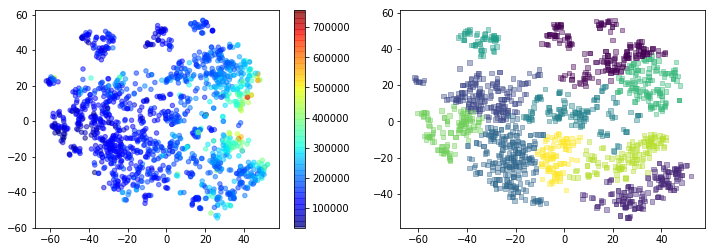

In [15]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
cmap = plt.cm.get_cmap('jet')
plt.scatter(tsne_representation[:len(y),0], tsne_representation[:len(y),1], 
            alpha=0.5, c=y, cmap=cmap, s=20)
plt.colorbar()
plt.subplot(1,2,2)
plt.scatter(tsne_representation[len(y):,0], tsne_representation[len(y):,1], 
            alpha=0.4, c=cl.labels_[len(y):], marker='s', s=20)

## Interactive plot with train and test data
Here **square** = test objects, **circle** = train objects

In [16]:
source_train = ColumnDataSource(
        data=dict(
            x = tsne_representation[:len(y),0],
            y = tsne_representation[:len(y),1],
            desc = y,
            colors = ["#%02x%02x%02x" % (int(r), int(g), int(b)) for r, g, b, _ in 
                      255*mpl.cm.jet(mpl.colors.Normalize()(y.values))],
            OverallQual = df['OverallQual'].iloc[:len(y)],
            GrLivArea = df['GrLivArea'].iloc[:len(y)],
            GarageCars = df['GarageCars'].iloc[:len(y)]
        )
    )

source_test = ColumnDataSource(
        data=dict(
            x = tsne_representation[len(y):,0],
            y = tsne_representation[len(y):,1],
            OverallQual = df['OverallQual'].iloc[len(y):],
            GrLivArea = df['GrLivArea'].iloc[len(y):],
            GarageCars = df['GarageCars'].iloc[len(y):]
        )
    )

hover_tsne = HoverTool(names=["test", "train"], tooltips=[("Price", "@desc"), 
                                 ("OverallQual", "@OverallQual"), 
                                 ("GrLivArea", "@GrLivArea"), 
                                 ("GarageCars", "@GarageCars")])
tools_tsne = [hover_tsne, 'pan', 'wheel_zoom', 'reset']
plot_tsne = figure(plot_width=600, plot_height=600, tools=tools_tsne, title='Prices')

plot_tsne.square('x', 'y', size=7, fill_color='orange', 
                 alpha=0.9, line_width=0, source=source_test, name="test")
plot_tsne.circle('x', 'y', size=10, fill_color='colors', 
                 alpha=0.5, line_width=0, source=source_train, name="train")

show(plot_tsne)